In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.widgets import Slider
from scipy import ndimage as sho

from skimage.feature import peak_local_max
from skimage.segmentation import watershed

from scipy import ndimage
import pandas as pd
from pandas import value_counts

import os
import glob
import json 
import math
import random






all_images = glob.glob(r'Images\Raw2\*.tif')
print(all_images)


['Images\\Raw2\\YZ00.tif', 'Images\\Raw2\\YZ01.tif', 'Images\\Raw2\\YZ02.tif', 'Images\\Raw2\\YZ03.tif', 'Images\\Raw2\\YZ05.tif', 'Images\\Raw2\\YZ07.tif', 'Images\\Raw2\\YZ08.tif', 'Images\\Raw2\\YZ09.tif', 'Images\\Raw2\\YZ10.tif', 'Images\\Raw2\\YZ11.tif', 'Images\\Raw2\\YZ12.tif', 'Images\\Raw2\\YZ13.tif', 'Images\\Raw2\\YZ14.tif', 'Images\\Raw2\\YZ15.tif', 'Images\\Raw2\\YZ16.tif', 'Images\\Raw2\\YZ17.tif', 'Images\\Raw2\\YZ18.tif', 'Images\\Raw2\\YZ19.tif', 'Images\\Raw2\\YZ20.tif', 'Images\\Raw2\\YZ21.tif', 'Images\\Raw2\\YZ22.tif', 'Images\\Raw2\\YZ23.tif', 'Images\\Raw2\\YZ24.tif', 'Images\\Raw2\\YZ25.tif', 'Images\\Raw2\\YZ26.tif', 'Images\\Raw2\\YZ27.tif', 'Images\\Raw2\\YZ28.tif', 'Images\\Raw2\\YZ29.tif', 'Images\\Raw2\\YZ30.tif', 'Images\\Raw2\\YZ31.tif', 'Images\\Raw2\\YZ32.tif', 'Images\\Raw2\\YZ33.tif', 'Images\\Raw2\\YZ34.tif', 'Images\\Raw2\\YZ35.tif', 'Images\\Raw2\\YZ36.tif', 'Images\\Raw2\\YZ37.tif', 'Images\\Raw2\\YZ38.tif', 'Images\\Raw2\\YZ39.tif', 'Images\\Ra

In [7]:
# create export directory next to the source images
export_dir = os.path.join(os.path.dirname("Images\Rawpng"))
os.makedirs(export_dir, exist_ok=True)

saved = 0
for image_path in all_images:
	img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
	if img is None:
		print("Failed to read:", image_path)
		continue

	# build export filename and path
	export_name = os.path.splitext(os.path.basename(image_path))[0] + ".png"
	export_path = os.path.join(export_dir, export_name)

	# convert 16-bit -> 8-bit if necessary
	if img.dtype == np.uint16:
		# scale 0-65535 to 0-255
		img_to_save = cv2.convertScaleAbs(img, alpha=(255.0/65535.0))
	else:
		img_to_save = img

	# ensure color order is BGR for cv2.imwrite (if using RGB arrays, convert back)
	# here images were read by cv2 so this is fine
	if cv2.imwrite(export_path, img_to_save):
		saved += 1
	else:
		print("Failed to write:", export_path)

print(f"Saved {saved}/{len(all_images)} PNGs to: {export_dir}")



Saved 48/48 PNGs to: Images


In [ ]:
all_images = glob.glob(r'Images\Rawpng\*.png')



batch_size = 5
num_batches = math.ceil(len(all_images) / batch_size)
print("Total de imágenes encontradas:", len(all_images))
print(all_images)



Total de imágenes encontradas: 48
['Images\\Rawpng\\YZ00.png', 'Images\\Rawpng\\YZ01.png', 'Images\\Rawpng\\YZ02.png', 'Images\\Rawpng\\YZ03.png', 'Images\\Rawpng\\YZ05.png', 'Images\\Rawpng\\YZ07.png', 'Images\\Rawpng\\YZ08.png', 'Images\\Rawpng\\YZ09.png', 'Images\\Rawpng\\YZ10.png', 'Images\\Rawpng\\YZ11.png', 'Images\\Rawpng\\YZ12.png', 'Images\\Rawpng\\YZ13.png', 'Images\\Rawpng\\YZ14.png', 'Images\\Rawpng\\YZ15.png', 'Images\\Rawpng\\YZ16.png', 'Images\\Rawpng\\YZ17.png', 'Images\\Rawpng\\YZ18.png', 'Images\\Rawpng\\YZ19.png', 'Images\\Rawpng\\YZ20.png', 'Images\\Rawpng\\YZ21.png', 'Images\\Rawpng\\YZ22.png', 'Images\\Rawpng\\YZ23.png', 'Images\\Rawpng\\YZ24.png', 'Images\\Rawpng\\YZ25.png', 'Images\\Rawpng\\YZ26.png', 'Images\\Rawpng\\YZ27.png', 'Images\\Rawpng\\YZ28.png', 'Images\\Rawpng\\YZ29.png', 'Images\\Rawpng\\YZ30.png', 'Images\\Rawpng\\YZ31.png', 'Images\\Rawpng\\YZ32.png', 'Images\\Rawpng\\YZ33.png', 'Images\\Rawpng\\YZ34.png', 'Images\\Rawpng\\YZ35.png', 'Images\\Rawp

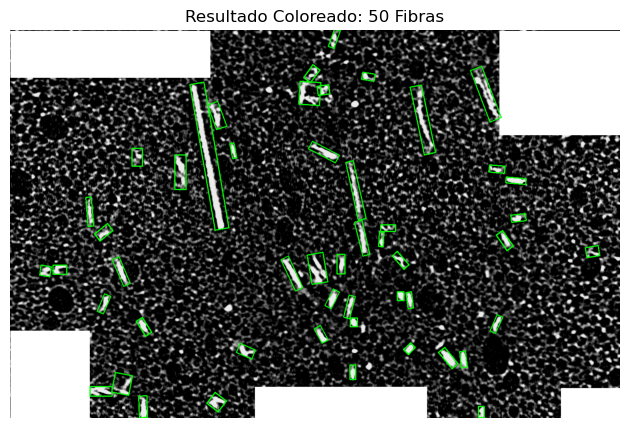

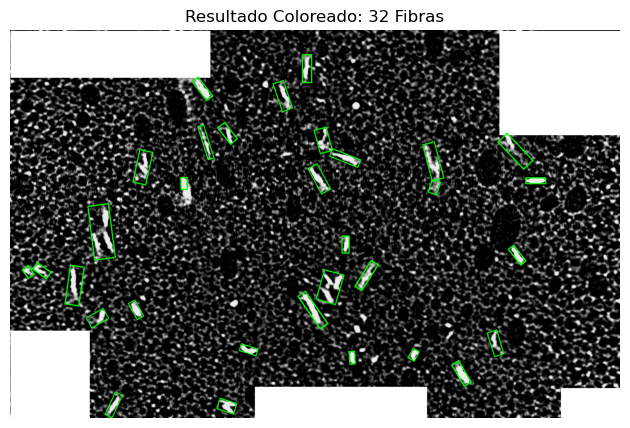

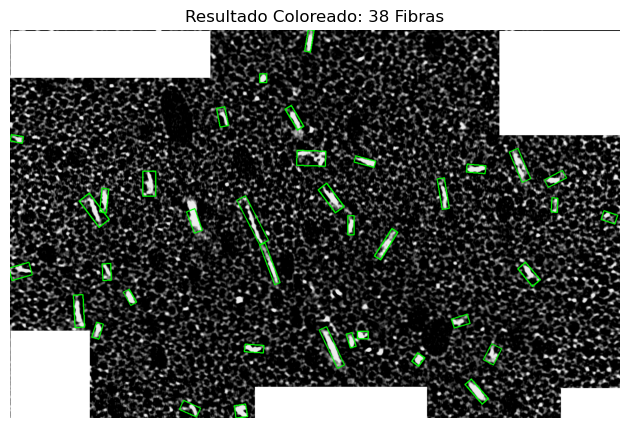

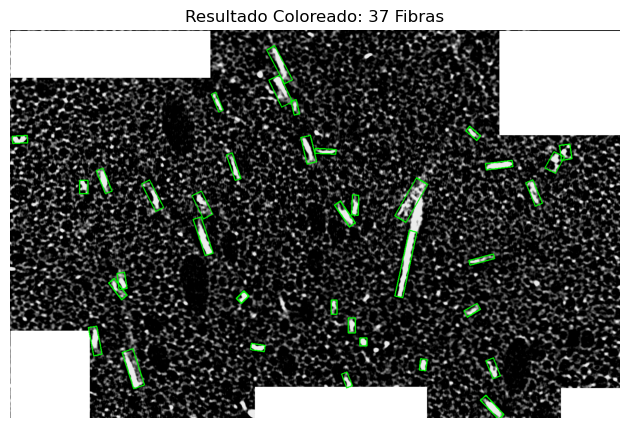

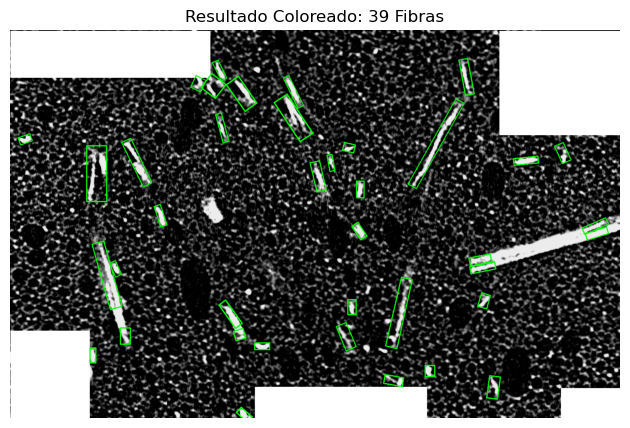

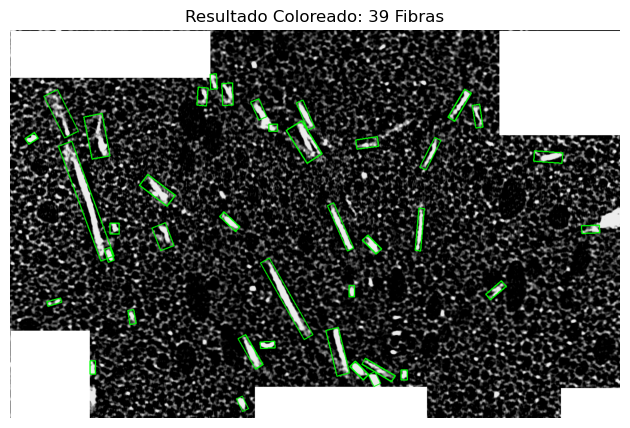

In [27]:
min_area_threshold = 250       
max_area_threshold = 15000    
min_aspect_ratio = 1       
min_rectangularity = 0.05     
min_brightness = 150

# process only the first 6 images
batch_images = all_images[18:24]
batch_data = []

for image_path in batch_images:
	image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
	if image is None:
		print(f"Warning: could not read {image_path}")
		continue

	# convert 16-bit -> 8-bit if necessary
	if image.dtype == np.uint16:
		image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

	# convert to grayscale if not already
	image_gray = image.copy() if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
	h_img, w_img = image_gray.shape

	# Labeling
	json_filename = image_path.replace(".png", ".json")

	# Processing
	kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
	tophat = cv2.morphologyEx(image_gray, cv2.MORPH_TOPHAT, kernel_tophat)
	_, binary = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
	kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
	clean_binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_clean, iterations=1)
	contours, _ = cv2.findContours(clean_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

	shapes = []
	result_img = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)
	count = 0

	for cnt in contours:
		area = cv2.contourArea(cnt)
		if not (min_area_threshold <= area <= max_area_threshold):
			continue

		mask = np.zeros(image_gray.shape, dtype=np.uint8)
		cv2.drawContours(mask, [cnt], 0, 255, -1)
		mean_val = cv2.mean(image_gray, mask=mask)[0]
		if mean_val < min_brightness:
			continue

		rect = cv2.minAreaRect(cnt)
		(x, y), (w, h), angle = rect
		if w == 0 or h == 0:
			continue

		aspect_ratio = max(w, h) / min(w, h)
		rectangularity = area / (w * h)
		if aspect_ratio >= min_aspect_ratio and rectangularity >= min_rectangularity:
			count += 1
			box = cv2.boxPoints(rect)
			points_list = box.tolist()
			box = box.astype(int)

			shapes.append({
				"label": "fibra",
				"points": points_list,
				"group_id": None,
				"description": "",
				"shape_type": "polygon",
				"flags": {}
			})
			cv2.drawContours(result_img, [box], 0, (0, 255, 0), 2)

	labelme_data = {
		"version": "5.2.1",
		"flags": {},
		"shapes": shapes,
		"imagePath": os.path.basename(image_path),
		"imageData": None,
		"imageHeight": h_img,
		"imageWidth": w_img
	}

	plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
	plt.title(f'Resultado Coloreado: {count} Fibras')
	plt.axis('off')
	plt.tight_layout()
	plt.show()

	with open(json_filename, "w") as f:
		json.dump(labelme_data, f, indent=2)


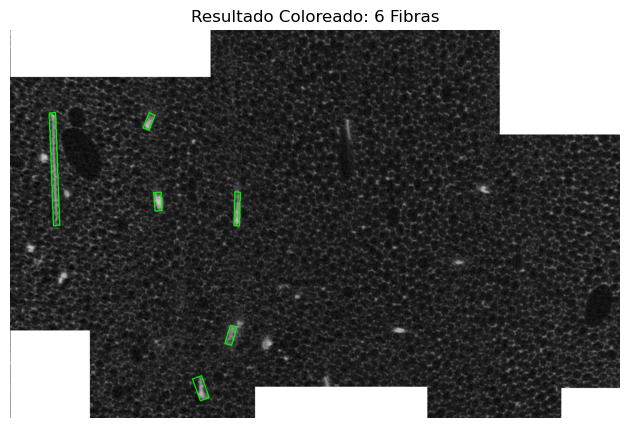

In [ ]:

# 1. Configuración de parámetros ajustados
min_area_threshold = 400       # Ignorar puntitos de ruido
max_area_threshold = 15000    # Suficiente para las fibras largas
min_aspect_ratio = 1       # Exigimos que sea alargado
min_rectangularity = 0.05     # Muy bajo para permitir fibras curvas o diagonales irregulares
min_brightness = 100


#Loop Labelme 

# Asumiendo que 'image' es tu imagen original cargada
image_gray = image.copy() if len(image.shape) == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Filtro Top-Hat: El secreto para extraer las fibras
# Usamos un kernel rectangular que sea un poco más grueso que el ancho de tus fibras
kernel_tophat = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
tophat = cv2.morphologyEx(image_gray, cv2.MORPH_TOPHAT, kernel_tophat)

# 3. Binarización sobre la imagen Top-Hat
# Como el Top-Hat ya oscureció el fondo, Otsu funcionará mucho mejor
_, binary = cv2.threshold(tophat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Limpieza Morfológica ligera (para borrar pequeñas manchas que hayan sobrevivido)
kernel_clean = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
clean_binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel_clean, iterations=1)

# 5. Búsqueda directa de contornos (¡Adiós Watershed!)
contours, _ = cv2.findContours(clean_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result_img = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)
count = 0

for cnt in contours:
    area = cv2.contourArea(cnt)
    
    if min_area_threshold <= area <= max_area_threshold:
        
        # ---------------------------------------------------------
        # NUEVO FILTRO DE INTENSIDAD (BLANCURA)
        # ---------------------------------------------------------
        # Creamos una máscara negra del tamaño de la imagen
        mask = np.zeros(image_gray.shape, dtype=np.uint8)
        # Dibujamos solo el contorno actual relleno de blanco
        cv2.drawContours(mask, [cnt], 0, 255, -1)
        # Calculamos el promedio de los píxeles originales que caen en la máscara
        mean_val = cv2.mean(image_gray, mask=mask)[0]
        
        # Si el objeto no es lo suficientemente blanco, lo ignoramos
        if mean_val < min_brightness:
            continue
        # ---------------------------------------------------------

        # Filtros Geométricos
        rect = cv2.minAreaRect(cnt)
        (x, y), (w, h), angle = rect
        
        if w == 0 or h == 0: continue
        
        aspect_ratio = max(w, h) / min(w, h)
        rect_area = w * h
        rectangularity = area / rect_area
        
        if aspect_ratio >= min_aspect_ratio and rectangularity >= min_rectangularity:
            count += 1
            box = cv2.boxPoints(rect)
            box = box.astype(int)
            cv2.drawContours(result_img, [box], 0, (0, 255, 0), 2)



plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title(f'Resultado Coloreado: {count} Fibras')
plt.axis('off')

plt.tight_layout()
plt.show()